**ENCODER-DECODER**

**Limitation of RNN??**

1- Vanishing Gradient -> RNN model is not able to remember the long term information

**TO SOLVE THE PROBLEM / LIMITATION OF RNN??**

- LSTM (Long -Short term Memory) -> RNN + Gate Mechanism

**SEQUENCE - TO- SEQUENCE MODELS**

- It is a type of neural network used when both the input and output are sequences(ordered data)

- Take a sequence as input

- process it

- Generates another sequence as output

In [ ]:
# ALSO CALLED ENCODER - DECODER ARCHITECTURE

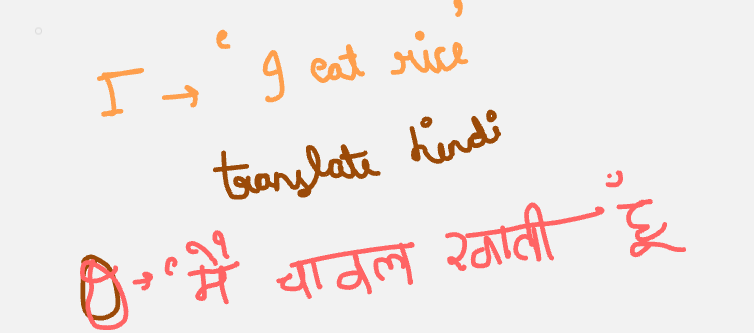

In [ ]:
# Input and Output sequences may have different length and normal RNN cannot handle this easily

In [ ]:
# SPLIT MODEL INTO TWO PARTS ??
# ENCODER
# DECODER

**Encoder-Decoder is a neural network architecture where one network reads the input sentence and another network generates the output sentence.**

In [ ]:
# ENCODER -> read the entire input sentence

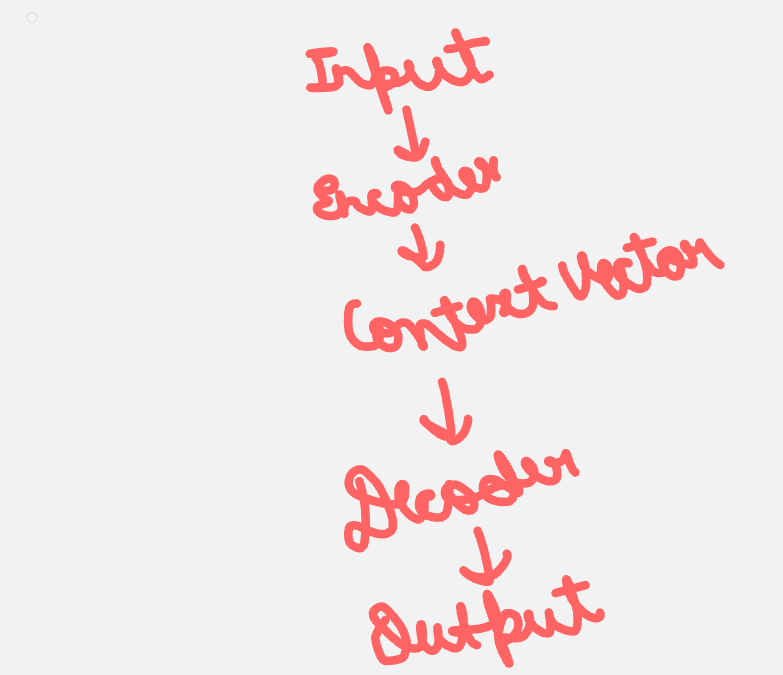

**HANDSON IMPLEMENTATION**

In [ ]:
import tensorflow as tf
import numpy as np
from collections import Counter
import random

In [ ]:
data = [ ("i am happy","मैं खुश हूँ"),
         ("You are sad","आप दुखी हैं"),
         ("she is tired", "वह थक गया है"),
         ("we are hungry","हम भूखें है"),
         ("they are busy","वे व्यस्त हैं"),
         ("i am cold","मुझे ठंड लग रही है"),
         ("you are late","तुम देरी से आए हो"),
         ("she is happy", "वह खुश है"),
         ("we are ready","हम तैयार हैं")]


In [ ]:
data[0]

('i am happy', 'मैं खुश हूँ')

In [ ]:
data[0][0]

'i am happy'

In [ ]:
# english sentence -> INPUT
# hindi sentence -> OUTPUT

In [ ]:
# SEPARETE ENGLISH SEQUENCE AND HINDI SEQUENCE
eng_sentence = []
hin_sentence=[]

for pair in data:
  eng_sentence.append(pair[0])
  hin_sentence.append(pair[1])

In [ ]:
eng_sentence

['i am happy',
 'You are sad',
 'she is tired',
 'we are hungry',
 'they are busy',
 'i am cold',
 'you are late',
 'she is happy',
 'we are ready']

In [ ]:
hin_sentence

['मैं खुश हूँ',
 'आप दुखी हैं',
 'वह थक गया है',
 'हम भूखें है',
 'वे व्यस्त हैं',
 'मुझे ठंड लग रही है',
 'तुम देरी से आए हो',
 'वह खुश है',
 'हम तैयार हैं']

In [ ]:
# TOKENIZATION (split the text into tokens)
# 9:22 p.m
eng_tokens = []
hin_tokens = []

for i in eng_sentence:
    eng_tokens.append(i.split())

for i in hin_sentence:
    hin_tokens.append(i.split())

In [ ]:
eng_tokens

[['i', 'am', 'happy'],
 ['You', 'are', 'sad'],
 ['she', 'is', 'tired'],
 ['we', 'are', 'hungry'],
 ['they', 'are', 'busy'],
 ['i', 'am', 'cold'],
 ['you', 'are', 'late'],
 ['she', 'is', 'happy'],
 ['we', 'are', 'ready']]

In [ ]:
# BECAUSE MODEL CAN'T UNDERSTAND FULL SENTENCES , IT NEEDS WORD-BY -WORD INPUT
# SO WE HAVE PERFORMED TOKENIZATION

**VOCAB -** list all the unique words(tokens)

In [ ]:
eng_vocab=[]
hin_vocab =[]

for i in eng_tokens:
  for j in i:
    eng_vocab.append(j)

for i in hin_tokens:
  for j in i:
    hin_vocab.append(j)



In [ ]:
eng_vocab

['i',
 'am',
 'happy',
 'You',
 'are',
 'sad',
 'she',
 'is',
 'tired',
 'we',
 'are',
 'hungry',
 'they',
 'are',
 'busy',
 'i',
 'am',
 'cold',
 'you',
 'are',
 'late',
 'she',
 'is',
 'happy',
 'we',
 'are',
 'ready']

In [ ]:
# SO THERE ARE MULTIPLE TOKENS WHICH ARE REPEATING
# NOW WE NEED TO FIND UNIQUE TOKENS

In [ ]:
eng_vocab = list(set(eng_vocab))
hin_vocab = list(set(hin_vocab))

In [ ]:
eng_vocab

['late',
 'You',
 'cold',
 'is',
 'i',
 'they',
 'sad',
 'she',
 'hungry',
 'busy',
 'you',
 'happy',
 'ready',
 'we',
 'am',
 'tired',
 'are']

**convert words into numbers**

In [ ]:
eng_word2index = {}
hin_word2index = {}

# english word to index
for i , word in enumerate(eng_vocab):
  eng_word2index[word] =  i +1

for i , word in enumerate(hin_vocab):
  hin_word2index[word] =  i +1

In [ ]:
# WHY I+1?
# Because 0 is reserved for padding later

In [ ]:
eng_word2index

{'late': 1,
 'You': 2,
 'cold': 3,
 'is': 4,
 'i': 5,
 'they': 6,
 'sad': 7,
 'she': 8,
 'hungry': 9,
 'busy': 10,
 'you': 11,
 'happy': 12,
 'ready': 13,
 'we': 14,
 'am': 15,
 'tired': 16,
 'are': 17}

In [ ]:
# list of numbers for each sentence

In [ ]:
eng_sequences =[]
hin_sequences = []

# English
for sent in eng_tokens:
  temp=[]
  for word in sent:
    temp.append(eng_word2index[word])
  eng_sequences.append(temp)

# Hindi
for sent in hin_tokens:
  temp=[]
  for word in sent:
    temp.append(hin_word2index[word])
  hin_sequences.append(temp)

In [ ]:
hin_sequences

[[22, 17, 19],
 [21, 8, 10],
 [1, 24, 6, 7],
 [11, 3, 7],
 [16, 4, 10],
 [12, 5, 18, 20, 7],
 [14, 9, 23, 15, 13],
 [1, 17, 7],
 [11, 2, 10]]

In [ ]:
# Add <start> and <end> token

In [ ]:
# Add token to dictionary
hin_word2index['<start>'] = len(hin_word2index)+1
hin_word2index['<end>'] = len(hin_word2index)+1

In [ ]:
new_hin_sequences = []
for seq in hin_sequences:
  start = hin_word2index['<start>']
  end = hin_word2index['<end>']

  new_seq = [start] + seq + [end]
  new_hin_sequences.append(new_seq)

hin_sequences = new_hin_sequences

In [ ]:
new_hin_sequences

[[25, 22, 17, 19, 26],
 [25, 21, 8, 10, 26],
 [25, 1, 24, 6, 7, 26],
 [25, 11, 3, 7, 26],
 [25, 16, 4, 10, 26],
 [25, 12, 5, 18, 20, 7, 26],
 [25, 14, 9, 23, 15, 13, 26],
 [25, 1, 17, 7, 26],
 [25, 11, 2, 10, 26]]

In [ ]:
# OUR SEQUENCE HAS DIFFERENT LENGTH , SO WE WILL PERFORM HERE PADDING
# PADDING -> arranging/matching all the sequence into the same length

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

eng_sequences = pad_sequences(eng_sequences,padding='post')
hin_sequences = pad_sequences(hin_sequences,padding='post')

In [ ]:
hin_sequences

array([[25, 22, 17, 19, 26,  0,  0],
       [25, 21,  8, 10, 26,  0,  0],
       [25,  1, 24,  6,  7, 26,  0],
       [25, 11,  3,  7, 26,  0,  0],
       [25, 16,  4, 10, 26,  0,  0],
       [25, 12,  5, 18, 20,  7, 26],
       [25, 14,  9, 23, 15, 13, 26],
       [25,  1, 17,  7, 26,  0,  0],
       [25, 11,  2, 10, 26,  0,  0]], dtype=int32)

**MODEL BUILDING**

In [ ]:
# define sizes
eng_vocab_size = len(eng_word2index)+1
hin_vocab_size = len(hin_word2index)+1

embedding_dim = 64
units = 128

In [ ]:
# encoder input
encoder_inputs = tf.keras.Input(shape=(None,))
# ANY LENGTH OF INPUT IS ALLOWED

In [ ]:
encoder_embedding = tf.keras.layers.Embedding(eng_vocab_size,embedding_dim)(encoder_inputs)

In [ ]:
# 10:20
encoder_lstm = tf.keras.layers.LSTM(units, return_state=True)
encoder_output, state_h, state_c = encoder_lstm(encoder_embedding)


In [ ]:
decoder_inputs = tf.keras.Input(shape=(None,))
decoder_inputs

decoder_embedding = tf.keras.layers.Embedding(hin_vocab_size, embedding_dim)(decoder_inputs)

decoder_embedding
decoder_lstm = tf.keras.layers.LSTM(units, return_sequences=True, return_state=True)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding, initial_state=[state_h, state_c]
)

decoder_dense = tf.keras.layers.Dense(hin_vocab_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

model = tf.keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')


In [ ]:
decoder_input_data = hin_sequences[:, :-1]
decoder_output_data = hin_sequences[:, 1:]

model.fit(
    [eng_sequences, decoder_input_data],
    decoder_output_data,
    epochs=200
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 3.2973
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 3.2885
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 3.2796
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 3.2701
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 3.2598
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 3.2483
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 3.2351
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 3.2197
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 3.2017
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 3.1801
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 3.1543
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 3.1230
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 3.0847
Epoch 14/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 3.0377
Epoch 15/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 2.9798
Epoch 16/200
1/1 ━━━

In [ ]:
# TESTING

In [ ]:
def translate_step_by_step(sentence):
    print("\nInput Sentence:", sentence)

    # Step 1: Convert to numbers
    test_seq = [eng_word2index[word] for word in sentence.split()]
    test_seq = np.array(test_seq).reshape(1, -1)

    print("Converted to numbers:", test_seq)

    # Step 2: Start with <start>
    start_token = hin_word2index['<start>']
    end_token = hin_word2index['<end>']

    decoder_input = np.array([[start_token]])

    print("Starting decoder with <start>\n")

    output = []

    for step in range(10):
        pred = model.predict([test_seq, decoder_input])

        next_word = np.argmax(pred[0, -1, :])

        # convert number → word
        idx2word = {v:k for k,v in hin_word2index.items()}
        word = idx2word.get(next_word, "?")

        print(f"Step {step+1}: Predicted word → {word}")

        if next_word == end_token:
            print("Reached <end> token. STOP.")
            break

        output.append(word)

        # add to decoder input
        decoder_input = np.append(decoder_input, [[next_word]], axis=1)

    print("\nFinal Translation:", " ".join(output))


In [ ]:
translate_step_by_step('i am happy')


Input Sentence: i am happy
Converted to numbers: [[ 5 15 12]]
Starting decoder with <start>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
Step 1: Predicted word → मैं
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
Step 2: Predicted word → खुश
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Step 3: Predicted word → हूँ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Step 4: Predicted word → <end>
Reached <end> token. STOP.

Final Translation: मैं खुश हूँ
